In [369]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
from agcounts_filter import convert_AC
from scipy.stats import zscore
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

Récupération des données des accéléromètres et des annotations

In [ ]:
folder_path = "C:/Users/roman/Documents/BEaCHILD/X_et_Y" 
folder = os.listdir(folder_path)

#//////////////////////////////AJOUTER UNE LISTE QUI DIT DOM ET NON DOM POUR CHAQUE FICHIER (la les Y sont bien classés mais forcément les X)
#lst_indic_dom = ["LW","LW","LW"]

# Initialisation des listes contenant les données des capteurs
X_non_dom = []
X_dom = []
idx_X_non_dom = 0
idx_X_dom = 0
idx_Y_dom = 0
idx_Y_non_dom = 0

# Initialisation des listes contenant les annotations vidéos
Y_non_dom = [] 
Y_dom = []


#Parcourir les fichiers CSV
for file in folder[31:34]: #[0:7]
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    # Pour les cas ou il y a des annotations avant le start
    allow_start_dom = None
    allow_start_non_dom = None

    """********************************************************************** 1. Lecture des fichiers csv ******************************************************************************"""
    if extension == ".csv":

        # Visualisation des données des capteurs
        data_file = pd.read_csv(folder_path + "/" + file, header = 5, names = ["Timestamp","Gyro X","Gyro Y","Gyro Z","Accelerometer X","Accelerometer Y","Accelerometer Z","Event","Quat W","Quat X","Quat Y","Quat Z","None"])    

        # Conversion en AC 
        dom_AC = convert_AC(folder_path + "/" + file)

        # Enregistrement des données des capteurs dans les listes qui seront donnnées au classificateur
        if file[-11:-4] == "non_dom":
            list_dom_AC = dom_AC["AC"].tolist() # Conversion du type pd.serie en type list
            for ac in list_dom_AC :
                X_non_dom.append(ac)

        elif file[-7:-4] == "dom":
            list_dom_AC = dom_AC["AC"].tolist()
            for ac in list_dom_AC:
                X_dom.append(ac)

    """********************************************************** 2. Enregistrer les annotations ***************************************************************************"""

    if extension == ".xlsx":

        my_wb = openpyxl.load_workbook(folder_path + "/" + file) 
        my_sheet = my_wb.active

        # Initialisation des décalages : sert pour éviter le décalage du aux arrondis des annotations 
        decalage_dom = 0
        decalage_non_dom = 0

        for label in my_sheet["H"]: 

            """*********************************************** Récupération du début de Y ****************************************************"""
            # dom
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_LW" :
                start_dom = int(round(float(my_sheet.cell(label.row,13).value)))
                # Les annotations ne commencent pas la 0 sec de la vidéo : Ajout du décalage
                for decalage in range(start_dom):
                    Y_dom.append(None) #.append("différent start droit")
                previous_row_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_dom = True

            # non_dom 
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_RW" :
                start_non_dom = int(round(float(my_sheet.cell(label.row,13).value)))
                # Les annotations ne commencent pas la 0 sec de la vidéo : Ajout du décalage
                for decalage in range(start_non_dom):
                    Y_non_dom.append(None) 
                previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_non_dom = True

            """****************************************************** Récupération du contenu de Y ****************************************"""

            if label.value[0:2] == "LW" and allow_start_dom:

                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_dom.append(None) 
                    
                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value))) 
                for nb_sec in range(nb_repetitions): 
                    if X_dom and (len(Y_dom) == len(X_dom)) :
                        break
                    if label.value[3:13] == "sédentaire" or label.value[-2:] == "FA":
                        Y_dom.append("non mouvement")
                    elif label.value[-2:] == "GA":
                        Y_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_dom.append(None) 

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_dom = label.row


            elif label.value[0:2] == "RW" and allow_start_non_dom:
                
                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_non_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_non_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_non_dom.append(None) #.append("décalage annotations")

                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value)))
                for nb_sec in range(nb_repetitions): 
                    if X_non_dom and (len(Y_non_dom) == len(X_non_dom)): 
                        break
                    if label.value[3:13] == "sédentaire" or label.value[-2:] == "FA":
                        Y_non_dom.append("non mouvement")
                    elif label.value[-2:] == "GA":
                        Y_non_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_non_dom.append(None)

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_non_dom = label.row

        # CROPER X A LA LONGUEUR DE Y 
        X_dom = X_dom[:len(Y_dom)] 
        X_non_dom = X_non_dom[:len(Y_non_dom)]
        Y_dom = Y_dom[:len(X_dom)]
        Y_non_dom = Y_non_dom[:len(X_non_dom)]



On est dans le fichier : Autres
On est dans le fichier : Data_10_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_10_non_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_10_X.xlsx
6793
X_dom [114.73883387938018, 61.61980201201558, 37.64306044943742, 133.4053971921676, 188.55768348173987, 122.31925441237777, 49.040799340956916]
Y_dom ['mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement']
On est dans le fichier : Data_11_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_11_non_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_11_X.xlsx
10422
X_dom [114.73883387938018, 61.61980201201558, 37.64306044943742, 133.4053971921676, 188.55768348173987, 122.31925441237777, 49.040799340956916]
Y_dom ['mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement']
On est dans le fichie

Récupération des données du gyroscope

In [371]:
folder_path = "C:/Users/roman/Documents/BEaCHILD/X_et_Y" 
folder = os.listdir(folder_path)

# Initialisation des listes contenant les données des capteurs
X_gyro_dom = []
Y_gyro_dom = []
Z_gyro_dom = []
X_gyro_non_dom = []
Y_gyro_non_dom = []
Z_gyro_non_dom = []

for file in files: 
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    if extension == ".csv":
        # Récupération des données des capteurs
        data_file = pd.read_csv(folder_path + "/" + file, header = 5, names = ["Timestamp","Gyro X","Gyro Y","Gyro Z","Accelerometer X","Accelerometer Y","Accelerometer Z","Event","Quat W","Quat X","Quat Y","Quat Z","None"])    
        
        if file[-11:-4] == "non_dom":
            X_gyro_non_dom.extend(data_file["Gyro X"].values.tolist()) 
            Y_gyro_non_dom.extend(data_file["Gyro Y"].values.tolist()) 
            Z_gyro_non_dom.extend(data_file["Gyro Z"].values.tolist())
        
        elif file[-7:-4] == "dom":
            X_gyro_dom.extend(data_file["Gyro X"].values.tolist()) #.append(data_file["Gyro X"][data])
            Y_gyro_dom.extend(data_file["Gyro Y"].values.tolist()) #.append(data_file["Gyro Y"][data])
            Z_gyro_dom.extend(data_file["Gyro Z"].values.tolist()) #.append(data_file["Gyro Z"][data])
print(len(X_gyro_dom))

# ------------------------- Norme des mouvements ---------------------------
gyro_non_dom_data_128Hz = []
for i in range(len(X_gyro_non_dom)):#for i in range(0,len(X_gyro_dom), 128):
    coordonnes = np.array([X_gyro_non_dom[i], Y_gyro_non_dom[i], Z_gyro_non_dom[i]])
    norme = np.linalg.norm(coordonnes)
    gyro_non_dom_data_128Hz.append(norme)

gyro_dom_data_128Hz = []
for i in range(len(X_gyro_dom)):#for i in range(0,len(X_gyro_dom), 128):
    coordonnes = np.array([X_gyro_dom[i], Y_gyro_dom[i], Z_gyro_dom[i]])
    norme = np.linalg.norm(coordonnes)
    gyro_dom_data_128Hz.append(norme)

gyro_non_dom_data_128Hz = np.array(gyro_non_dom_data_128Hz)
gyro_dom_data_128Hz = np.array(gyro_dom_data_128Hz)
# --------------------------- Changement de fréquence : passage de 128Hz à 1Hz ---------------------------
def downsample_to_1Hz(binary_array, sampling_rate=128):
    n_seconds = len(binary_array) // sampling_rate
    binary_array = binary_array[:n_seconds * sampling_rate]  # tronquer pour être multiple de 128
    reshaped = binary_array.reshape(n_seconds, sampling_rate) # Majorité : si au moins 64 échantillons sont actifs, on considère la seconde comme mouvement
    return (reshaped.sum(axis=1) >= (sampling_rate // 2)).astype(int)

gyro_dom_data = downsample_to_1Hz(gyro_dom_data_128Hz)
gyro_non_dom_data = downsample_to_1Hz(gyro_non_dom_data_128Hz)

# Coupure des annotations prédictive à la longueur des données d'accélération (les données de mouvement ne sont pas toutes annotées)
gyro_dom_data = gyro_dom_data[:len(X_dom)]
gyro_non_dom_data = gyro_non_dom_data[:len(X_non_dom)]


On est dans le fichier : Autres
On est dans le fichier : Data_10_dom.csv
On est dans le fichier : Data_10_non_dom.csv
On est dans le fichier : Data_10_X.xlsx
On est dans le fichier : Data_11_dom.csv
On est dans le fichier : Data_11_non_dom.csv
On est dans le fichier : Data_11_X.xlsx
On est dans le fichier : Data_16_dom.csv
On est dans le fichier : Data_16_non_dom.csv
On est dans le fichier : Data_16_X.xlsx
On est dans le fichier : Data_2_dom.csv
On est dans le fichier : Data_2_non_dom.csv
On est dans le fichier : Data_2_X.xlsx
On est dans le fichier : Data_3_dom.csv
On est dans le fichier : Data_3_non_dom.csv
On est dans le fichier : Data_3_X.xlsx
On est dans le fichier : Data_4_dom.csv
On est dans le fichier : Data_4_non_dom.csv
On est dans le fichier : Data_4_X.xlsx
On est dans le fichier : Data_5_dom.csv
On est dans le fichier : Data_5_non_dom.csv
On est dans le fichier : Data_5_X.xlsx
On est dans le fichier : Data_6_dom.csv
On est dans le fichier : Data_6_non_dom.csv
On est dans le

Préaparation des données (nettoyage et équilibrage)

In [372]:
#-------------------------------------------------------------- Dominant ----------------------------------------------------
# Convertir en array pour faciliter le filtrage
X_array_dom = np.array(X_dom)
Y_array_dom = np.array(Y_dom)
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_None_dom = Y_array_dom != None
# Appliquer le masque
X_clean_dom = X_array_dom[mask_None_dom]
Y_clean_dom = Y_array_dom[mask_None_dom]

#Equilibrer les données : autant de mouvement que de non mouvement, et dans le meme ordre que X_array et Y_array
# Compter les "non mouvement"
n_non_mvt = np.sum(Y_clean_dom == 'non mouvement')
n_mvt = np.sum(Y_clean_dom == 'mouvement')
# Sélectionner les indices dans l’ordre original
indices_mvt = np.where(Y_clean_dom == 'mouvement')[0]
indices_non_mvt = np.where(Y_clean_dom == 'non mouvement')[0]
# Si plus de mouvement
if n_non_mvt < n_mvt:
    # Garder les premiers `mouvement` rencontrés dans l'ordre
    indices_mvt_crop = indices_mvt[:n_non_mvt]
    # Fusionner les indices en gardant l’ordre du tableau initial
    indices_final_dom = sorted(np.concatenate((indices_non_mvt, indices_mvt_crop)))
# Si plus de non mouvement
elif n_mvt < n_non_mvt :
    # Garder les premiers `non mouvement` rencontrés dans l'ordre
    indices_non_mvt_crop = indices_non_mvt[:n_mvt]
    # Fusionner les indices en gardant l’ordre du tableau initial
    indices_final_dom = sorted(np.concatenate((indices_mvt, indices_non_mvt_crop)))


# Réorganise X et Y
X_balanced_dom = X_clean_dom[indices_final_dom]
Y_balanced_dom = Y_clean_dom[indices_final_dom]
gyro_dom_data = gyro_dom_data[indices_final_dom]

# Aplatir les données (mettre au bon format pour les modèles)
X_flat_dom = np.vstack(X_balanced_dom)  # (n_total_samples, n_features)
Y_flat_dom = np.hstack(Y_balanced_dom)  # (n_total_samples,)


#-------------------------------------------------------------- Non dominant ----------------------------------------------------

# Convertir en array pour faciliter le filtrage
X_array_non_dom = np.array(X_non_dom)
Y_array_non_dom = np.array(Y_non_dom)
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_None_non_dom = Y_array_non_dom != None
# Appliquer le masque
X_clean_non_dom = X_array_non_dom[mask_None_non_dom]
Y_clean_non_dom = Y_array_non_dom[mask_None_non_dom]

#Equilibrer les données : autant de mouvement que de non mouvement, et dans le meme ordre que X_array et Y_array
# Compter les "non mouvement"
n_non_mvt = np.sum(Y_clean_non_dom == 'non mouvement')
n_mvt = np.sum(Y_clean_non_dom == 'mouvement')
# Sélectionner les indices dans l’ordre original
indices_mvt = np.where(Y_clean_non_dom == 'mouvement')[0]
indices_non_mvt = np.where(Y_clean_non_dom == 'non mouvement')[0]
# Si plus de mouvement
if n_non_mvt < n_mvt:
    # Garder les premiers `mouvement` rencontrés dans l'ordre
    indices_mvt_crop = indices_mvt[:n_non_mvt]
    # Fusionner les indices en gardant l’ordre du tableau initial
    indices_final_non_dom = sorted(np.concatenate((indices_non_mvt, indices_mvt_crop)))
# Si plus de non mouvement
elif n_mvt < n_non_mvt :
    # Garder les premiers `non mouvement` rencontrés dans l'ordre
    indices_non_mvt_crop = indices_non_mvt[:n_mvt]
    # Fusionner les indices en gardant l’ordre du tableau initial
    indices_final_non_dom = sorted(np.concatenate((indices_mvt, indices_non_mvt_crop)))

# Réorganise X et Y
X_balanced_non_dom = X_clean_non_dom[indices_final_non_dom]
Y_balanced_non_dom = Y_clean_non_dom[indices_final_non_dom]
#gyro_non_dom_data = gyro_non_dom_data[indices_final_non_dom]

# Aplatir les données (mettre au bon format pour les modèles)
X_flat_non_dom = np.vstack(X_balanced_non_dom)  # (n_total_samples, n_features)
Y_flat_non_dom = np.hstack(Y_balanced_non_dom)  # (n_total_samples,)
print(len(X_flat_non_dom))

#-------------------------------------------------------------- Dom et non dom à la même taille ----------------------------------------------------
"""X_flat_dom = X_flat_dom[:len(X_flat_non_dom)]
X_flat_non_dom = X_flat_non_dom[:len(X_flat_dom)]
Y_flat_dom = Y_flat_dom[:len(X_flat_dom)]
Y_flat_non_dom = Y_flat_non_dom[:len(X_flat_non_dom)]"""

6510


'X_flat_dom = X_flat_dom[:len(X_flat_non_dom)]\nX_flat_non_dom = X_flat_non_dom[:len(X_flat_dom)]\nY_flat_dom = Y_flat_dom[:len(X_flat_dom)]\nY_flat_non_dom = Y_flat_non_dom[:len(X_flat_non_dom)]'

Clustering

In [ ]:
def compute_features(acc_data, gyro_data):
    # ‖acc(tn)‖1 : somme des valeurs absolues
    acc_l1 = np.sum(np.abs(
        
    ))
    
    # Pwindow : 
    for idx_sec in range(0,len(acc_data), 10):
        print(idx_sec)
        power =  #np.mean(np.square(acc_data))
    
    # range(E) :
    energy = 0#np.sum(np.square(acc_data), axis=1)
    energy_range = 0#np.max(energy) - np.min(energy)
    
    # std(‖acc‖2) : écart-type de la norme L2
    acc_norms = np.linalg.norm(acc_data, axis=1)
    acc_std = np.std(acc_norms)

    return [acc_l1, power, energy_range, acc_std]

# Création de fenetres de 10 points
dom_features = []
non_dom_features = []

# Fenetres membre dominant
n_windows_dom = int(len(X_flat_dom) / 10) 
for i in range(n_windows_dom):
    dom_feats = compute_features(X_flat_dom[i*10:(i+1)*10], gyro_dom_data[i*10:(i+1)*10])
    dom_features.append(dom_feats)

# Fenetres membre non dominant
n_windows_non_dom = int(len(X_flat_non_dom) / 10) 
for i in range(n_windows_non_dom):
    non_dom_feats = compute_features(X_flat_non_dom[i*10:(i+1)*10], gyro_non_dom_data[i*10:(i+1)*10])
    non_dom_features.append(non_dom_feats)

# Convertir en DataFrame
df_dom_features = pd.DataFrame(dom_features, columns=['left_acc_l1', 'left_power', 'left_energy_range', 'left_acc_std'])
df_non_dom_features = pd.DataFrame(non_dom_features,columns =['right_acc_l1', 'right_power', 'right_energy_range', 'right_acc_std'])
#print(type(df_features))

# Normalisation Z-score
X_dom_scaled = zscore(df_dom_features)
X_non_dom_scaled = zscore(df_non_dom_features)

# --------------------------- Cluster dom -----------------------------
# Clustering K-means
dom_kmeans = KMeans(n_clusters=2, random_state=42)
dom_labels = dom_kmeans.fit_predict(X_dom_scaled)
# Interprétation des clusters
df_dom_features['cluster'] = dom_labels
df_dom_features['activity_label'] = df_dom_features['cluster'].map({0: 'non mouvement', 1: 'mouvement'})

# --------------------------- Cluster non dom -----------------------------
# Clustering K-means
non_dom_kmeans = KMeans(n_clusters=2, random_state=42)
non_dom_labels = non_dom_kmeans.fit_predict(X_non_dom_scaled)
# Interprétation des clusters
df_non_dom_features['cluster'] = non_dom_labels
df_non_dom_features['activity_label'] = df_non_dom_features['cluster'].map({0: 'non mouvement', 1: 'mouvement'})
print(len(df_non_dom_features['activity_label']))

651


c:\Users\roman\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\roman\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Affichage (prédictions / vérité) et analyse DOMINANT

11260
11262


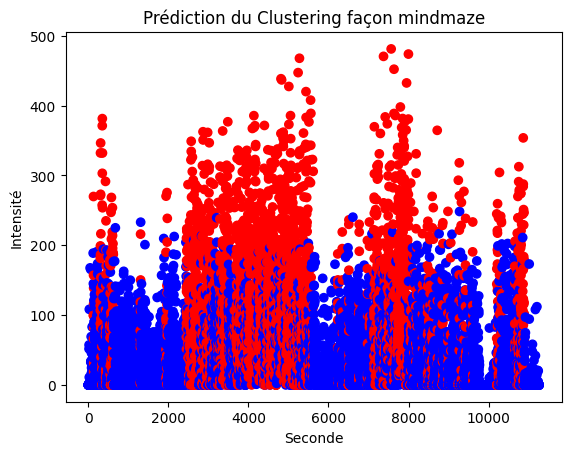

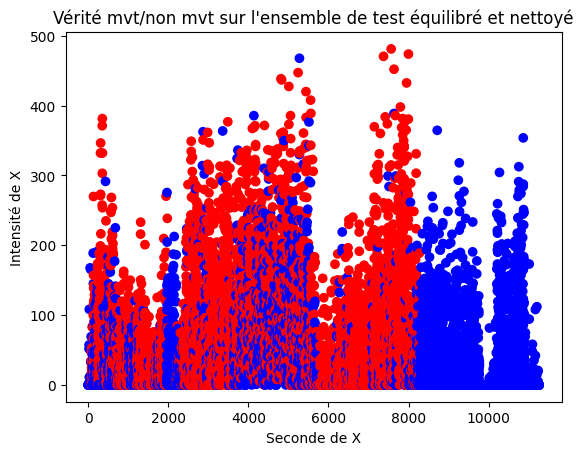

Accuracy pour clustering : 0.61


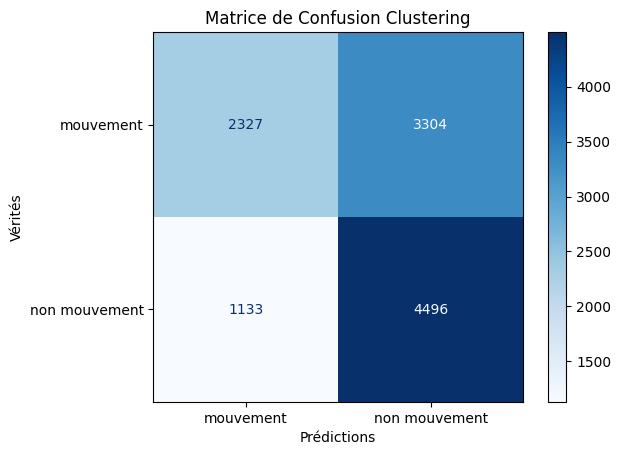

In [374]:
# Mapping de couleur
color_map = {'mouvement': 'red', 'non mouvement': 'blue'}
# Convertir les labels en couleurs
colors = []
Y_pred = []

for label in df_dom_features['activity_label']:

    # df_dom_features['activity_label'] c'est une prédiction pour 10 points, or on veut 1 prédiction pour 1 points
    for i in range(10):
        colors.append(color_map[label])
        Y_pred.append(label)

print(len(colors))
X_flat_dom_cut = X_flat_dom 
# Ajuster la taille de X_flat
if (len(X_flat_dom) - ((int(len(X_flat_dom) / 10 )) * 10)) != 0:
    to_cut = len(X_flat_dom) - ((int(len(X_flat_dom) / 10 )) * 10) # ex data 10 : 952 - 950
    X_flat_dom_cut = X_flat_dom[:-to_cut]
    Y_flat_dom = Y_flat_dom[:-to_cut]

print(len(X_flat_dom))
plt.scatter(range(len(X_flat_dom_cut)), X_flat_dom_cut, c = colors)
plt.xlabel("Seconde")
plt.ylabel("Intensité")
plt.title("Prédiction du Clustering façon mindmaze")
plt.show()


color_map = {'mouvement': 'red', 'non mouvement': 'blue'}
# Convertir les labels en couleurs
colors = [color_map[label] for label in Y_flat_dom]

plt.scatter(range(len(X_flat_dom_cut)), X_flat_dom_cut, c=colors) 
plt.title("Vérité mvt/non mvt sur l'ensemble de test équilibré et nettoyé")
plt.xlabel("Seconde de X")
plt.ylabel("Intensité de X")
plt.show()


# Evaluer le modèle
accuracy = accuracy_score(Y_flat_dom, Y_pred)
print(f"Accuracy pour clustering : {accuracy:.2f}")
cm_cluster = confusion_matrix(Y_flat_dom, Y_pred)

# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cluster, display_labels= ["mouvement", "non mouvement"])
disp.plot(cmap="Blues")
disp.ax_.set_title("Matrice de Confusion Clustering")
disp.ax_.set_xlabel("Prédictions")
disp.ax_.set_ylabel("Vérités")
#disp.figure_.show()
plt.show()